# Analyzing DHS microdata

* India 2015-2016 - we use this because 2019-2021 data would have been heavily impacted by COVID, and 2023-2024 microdata is not yet available.
* Nigeria 2023-2024
* Ethiopia 2016 - none of the more recent surveys include hemoglobin data.

## Documentation

DHS 7 recode manual for variable definitions: https://www.dhsprogram.com/pubs/pdf/DHSG4/Recode7_DHS_10Sep2018_DHSG4.pdf.
However, it does not state which variables are in which file.
The `.MAP` files alongside each data file list the variables in it and what they mean.

Hemoglobin variables of interest: 
- HA53: Hemoglobin level in g/dl with 1 implied dcimal
- HA54: Currently pregnant
- HA55 Result of Hemoglobin measuring.
- HA56 Hemoglobin level adjusted by altitude in g/dl with 1 implied decimal. 

Wealth index variables of interest: 
- HV270: The wealth index is a composite measure of a household's cumulative living standard.
The wealth index is calculated using easy-to-collect data on a household’s ownership of
selected assets, such as televisions and bicycles; materials used for housing construction; and
types of water access and sanitation facilities.
Generated with a statistical procedure known as principal components analysis, the wealth
index places individual households on a continuous scale of relative wealth. DHS separates
all interviewed households into five wealth quintiles to compare the influence of wealth on
various population, health and nutrition indicators. The wealth index is presented in the DHS
Final Reports and survey datasets as a background characteristic
- HV271: Wealth index factor score (5 decimals) 

Pregnancy variables of interest: 
- HML18: Pregnancy status from individual questionnaire. For complete woman’s interviews this is
taken from V213. For incomplete woman's interview with anemia testing the pregnancy
status is taken from this section.
BASE: Women with a completed individual questionnaire or when available information
from the anemia testing section.

List of datasets: https://www.dhsprogram.com/data/dataset/Nigeria_Standard-DHS_2018.cfm?flag=1

Instructions on how to calculate everything can be found at: https://www.dhsprogram.com/pubs/pdf/DHSG1/Guide_to_DHS_Statistics_DHS-7_v2.pdf

In [1]:
import pandas as pd, numpy as np
from lsff_utils import data_processing

%load_ext autoreload
%autoreload 2

!date

Fri 04 Sep 2026 12:25:38 PM PDT


In [2]:
location = "ethiopia"

In [3]:
# Parameters
location = "nigeria"


## Load data, name columns

In [4]:
directory = {
    "india": "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/",
    "nigeria": "/snfs1/DATA/DHS_PROG_DHS/NGA/2023_2024/",
    "ethiopia": "/snfs1/DATA/DHS_PROG_DHS/ETH/2016/",
}[location]

### WRA

In [5]:
%%time

wra_data_file_name = {
    "india": "IND_DHS7_2015_2016_WN_IAIR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS8_2023_2024_WN_NGIR8AFL_Y2025M10D30.DTA",
    "ethiopia": "ETH_DHS7_2016_WN_ETIR71FL_Y2019M12D11.DTA",
}[location]

wra_columns = {
    "v001": "cluster_number",
    "v002": "household_number",
    "v003": "line_number",
    "v005": "weight",
    "v008": "interview_date",
    "v011": "date_of_birth",
    "v190": "wealth_quintile",
    "v213": "currently_pregnant",
}
wra_data = pd.read_stata(
    directory + wra_data_file_name,
    columns=wra_columns.keys(),
)

CPU times: user 3.02 s, sys: 574 ms, total: 3.6 s
Wall time: 3.71 s


In [6]:
wra_data = wra_data[wra_columns.keys()].rename(columns=wra_columns)

In [7]:
wra_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    wra_data.wealth_quintile
)

In [8]:
wra_data["pregnant"] = wra_data.currently_pregnant.str.strip().map(
    {
        "not pregnant, don't know": "not_pregnant",
        "no or unsure": "not_pregnant",
        "pregnant": "pregnant",
        "yes": "pregnant",
    }
)

In [9]:
wra_data["weight"] = wra_data.weight / 1_000_000

### Births

In [10]:
birth_data_file_name = {
    "india": "IND_DHS7_2015_2016_BR_IABR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS8_2023_2024_BR_NGBR8AFL_Y2025M10D30.DTA",
    "ethiopia": "ETH_DHS7_2016_BR_ETBR71FL_Y2019M12D11.DTA",
}[location]

birth_columns = {
    "v005": "weight",
    "v008": "interview_date",
    "v190": "wealth_quintile",
    "b3": "birth_date",
    "m18": "size_of_child",
    "m19": "birth_weight_kilograms",
}
if location == "india":
    birth_columns["s220a"] = "duration_of_pregnancy"
else:
    birth_columns["b20"] = "duration_of_pregnancy"

birth_data = pd.read_stata(
    directory + birth_data_file_name,
    columns=birth_columns.keys(),
)
birth_data

,v005,v008,v190,b3,m18,m19,b20
0,491963,1489,poorer,1479,average,not weighed at birth,9
1,491963,1489,poorer,1409,NaN,NaN,9
2,491963,1489,poorer,1388,NaN,NaN,9
3,491963,1489,poorer,1339,NaN,NaN,9
4,491963,1489,poorer,1313,NaN,NaN,9
...,...,...,...,...,...,...,...
104552,507019,1490,middle,1211,NaN,NaN,9
104553,507019,1490,middle,1174,NaN,NaN,9
104554,507019,1490,middle,1143,NaN,NaN,9
104555,507019,1490,middle,1122,NaN,NaN,9


In [11]:
birth_data = birth_data[birth_columns.keys()].rename(columns=birth_columns)
birth_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    birth_data.wealth_quintile
)
birth_data["weight"] = birth_data.weight / 1_000_000
birth_data

,weight,interview_date,wealth_quintile,birth_date,size_of_child,birth_weight_kilograms,duration_of_pregnancy
0,0.491963,1489,2,1479,average,not weighed at birth,9
1,0.491963,1489,2,1409,NaN,NaN,9
2,0.491963,1489,2,1388,NaN,NaN,9
3,0.491963,1489,2,1339,NaN,NaN,9
4,0.491963,1489,2,1313,NaN,NaN,9
...,...,...,...,...,...,...,...
104552,0.507019,1490,3,1211,NaN,NaN,9
104553,0.507019,1490,3,1174,NaN,NaN,9
104554,0.507019,1490,3,1143,NaN,NaN,9
104555,0.507019,1490,3,1122,NaN,NaN,9


### Household members

In [12]:
%%time

hhm_data_file_name = {
    "india": "IND_DHS7_2015_2016_HHM_IAPR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS8_2023_2024_HHM_NGPR8AFL_Y2025M10D30.DTA",
    "ethiopia": "ETH_DHS7_2016_HHM_ETPR71FL_Y2019M12D11.DTA",
}[location]

hhm_columns = {
    "hv001": "cluster_number",
    "hv002": "household_number",
    "hv005": "weight",
    "hv008": "date_of_interview",
    "hvidx": "line_number",
    "hv105": "age",
    "hv104": "sex",
    "ha0": "index_to_household",
    "ha1": "age_hemoglobin",
    "hv270": "wealth_quintile",
    "ha53": "hemoglobin_raw_adult",
    "ha56": "hemoglobin_adjusted_adult",
    "ha57": "anemia_adult",
    "hc53": "hemoglobin_raw_child",
    "hc56": "hemoglobin_adjusted_child",
    "hc57": "anemia_child",
}
hhm_data = pd.read_stata(
    directory + hhm_data_file_name,
    columns=hhm_columns.keys(),
)
hhm_data

CPU times: user 416 ms, sys: 140 ms, total: 556 ms
Wall time: 557 ms


,hv001,hv002,hv005,hv008,hvidx,hv105,hv104,ha0,ha1,hv270,ha53,ha56,ha57,hc53,hc56,hc57
0,1,2,508728,1489,1,76,female,NaN,NaN,poorer,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,508728,1489,2,35,female,2.0,35.0,poorer,124.0,124.0,not anemic,NaN,NaN,NaN
2,1,2,508728,1489,3,25,male,NaN,NaN,poorer,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,508728,1489,4,17,female,4.0,17.0,poorer,not present,NaN,NaN,NaN,NaN,NaN
4,1,2,508728,1489,5,15,male,NaN,NaN,poorer,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176040,1400,37,523136,1490,3,24,female,3.0,23.0,middle,164.0,164.0,not anemic,NaN,NaN,NaN
176041,1400,37,523136,1490,4,18,female,4.0,18.0,middle,121.0,121.0,not anemic,NaN,NaN,NaN
176042,1400,37,523136,1490,5,8,male,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN
176043,1400,38,523136,1490,1,77,female,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
hhm_data = hhm_data[hhm_columns.keys()].rename(columns=hhm_columns)

In [14]:
id_columns = ["cluster_number", "household_number", "line_number"]
hhm_data = hhm_data.merge(
    wra_data[id_columns + ["pregnant"]],
    on=id_columns,
    how="left",
)
hhm_data["pregnant"] = hhm_data.pregnant.fillna("not_pregnant")

In [15]:
hhm_data["age"] = hhm_data.age.replace({"95+": 95, "don't know": np.nan}).astype(float)

In [16]:
hhm_data["sex"] = hhm_data.sex.str.title()

In [17]:
# Interesting -- sometimes age is quite off between hemoglobin and base.
hhm_data.loc[(hhm_data.age - hhm_data.age_hemoglobin).sort_values().index]

,cluster_number,household_number,weight,date_of_interview,line_number,age,sex,index_to_household,age_hemoglobin,wealth_quintile,hemoglobin_raw_adult,hemoglobin_adjusted_adult,anemia_adult,hemoglobin_raw_child,hemoglobin_adjusted_child,anemia_child,pregnant
76198,477,49,2243114,1488,2,19.0,Female,2.0,45.0,poorest,130.0,130.0,not anemic,NaN,NaN,NaN,not_pregnant
95132,623,16,534355,1489,3,22.0,Female,3.0,48.0,poorest,126.0,126.0,not anemic,NaN,NaN,NaN,not_pregnant
35110,227,5,664975,1489,3,20.0,Female,3.0,43.0,poorer,153.0,153.0,not anemic,NaN,NaN,NaN,not_pregnant
144606,1085,59,670547,1488,7,19.0,Female,7.0,40.0,richest,131.0,131.0,not anemic,NaN,NaN,NaN,not_pregnant
83642,541,13,924990,1491,5,18.0,Female,5.0,39.0,richer,134.0,134.0,not anemic,NaN,NaN,NaN,not_pregnant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176037,1400,35,523136,1490,2,16.0,Male,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
176038,1400,37,523136,1490,1,59.0,Male,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
176042,1400,37,523136,1490,5,8.0,Male,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
176043,1400,38,523136,1490,1,77.0,Female,NaN,NaN,middle,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant


In [18]:
(hhm_data.age - hhm_data.age_hemoglobin).describe()

count    14711.000000
mean        -0.215213
std          1.652319
min        -26.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         17.000000
dtype: float64

In [19]:
age_bin_edges = [0, 5, 15, 30, 50, 125]
age_group = pd.IntervalIndex(
    pd.cut(hhm_data.age, age_bin_edges, right=False, include_lowest=True)
)
hhm_data["age_start"] = age_group.left
hhm_data["age_end"] = age_group.right

In [20]:
hhm_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    hhm_data.wealth_quintile
)
hhm_data["weight"] = hhm_data.weight / 1_000_000

In [21]:
for type in ["child", "adult"]:
    for base_col in ["hemoglobin_raw", "hemoglobin_adjusted"]:
        col = f"{base_col}_{type}"
        hhm_data[col] = (
            hhm_data[col]
            .astype(str)
            .replace(
                {
                    "not tested": np.nan,
                    "not present": np.nan,
                    "refused": np.nan,
                    "other": np.nan,
                }
            )
            .astype(float)
        )

In [22]:
for base_col in ["hemoglobin_raw", "hemoglobin_adjusted", "anemia"]:
    assert (hhm_data.filter(like=base_col).notnull().sum(axis=1) <= 1).all()
    hhm_data[base_col] = np.nan
    # Could use bfill instead of this loop, but it was incredibly slow for me
    for col in hhm_data.filter(like=base_col).columns:
        hhm_data[base_col] = hhm_data[base_col].fillna(hhm_data[col])

In [23]:
assert (
    hhm_data[(hhm_data.sex == "male") & (hhm_data.age > 5)]
    .hemoglobin_raw.isnull()
    .all()
)

## Hemoglobin

In [24]:
other_overlapping_columns = (
    (set(wra_data.columns) & set(hhm_data.columns)) - set(id_columns) - {"weight"}
)
other_overlapping_columns

{'pregnant', 'wealth_quintile'}

In [25]:
wra_hhm_joined = wra_data.merge(
    hhm_data.drop(columns=["weight"]),
    on=id_columns,
    suffixes=("_wra", "_hhm"),
    how="left",
)
wra_hhm_joined

,cluster_number,household_number,line_number,weight,interview_date,date_of_birth,wealth_quintile_wra,currently_pregnant,pregnant_wra,date_of_interview,...,anemia_adult,hemoglobin_raw_child,hemoglobin_adjusted_child,anemia_child,pregnant_hhm,age_start,age_end,hemoglobin_raw,hemoglobin_adjusted,anemia
0,1,2,2,0.491963,1489,1062,2,no or unsure,not_pregnant,1489,...,not anemic,NaN,NaN,NaN,not_pregnant,30.0,50.0,124.0,124.0,not anemic
1,1,2,4,0.491963,1489,1277,2,no or unsure,not_pregnant,1489,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
2,1,6,2,0.491963,1489,1049,2,no or unsure,not_pregnant,1489,...,NaN,NaN,NaN,NaN,not_pregnant,30.0,50.0,NaN,NaN,NaN
3,1,9,5,0.491963,1489,1235,2,no or unsure,not_pregnant,1489,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
4,1,9,7,0.491963,1489,1251,2,no or unsure,not_pregnant,1489,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39045,1400,28,4,0.507019,1490,1285,3,no or unsure,not_pregnant,1490,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
39046,1400,31,2,0.507019,1490,1237,3,no or unsure,not_pregnant,1490,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
39047,1400,37,2,0.507019,1490,909,3,no or unsure,not_pregnant,1490,...,mild,NaN,NaN,NaN,not_pregnant,30.0,50.0,113.0,113.0,mild
39048,1400,37,3,0.507019,1490,1211,3,no or unsure,not_pregnant,1490,...,not anemic,NaN,NaN,NaN,not_pregnant,15.0,30.0,164.0,164.0,not anemic


In [26]:
for col in other_overlapping_columns:
    assert (wra_hhm_joined[f"{col}_wra"] == wra_hhm_joined[f"{col}_hhm"]).all()
    wra_hhm_joined[col] = wra_hhm_joined[f"{col}_wra"]
    wra_hhm_joined = wra_hhm_joined.drop(columns=[f"{col}_wra", f"{col}_hhm"])

In [27]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [28]:
pregnant_with_anemia_status = wra_hhm_joined[
    (wra_hhm_joined.pregnant == "pregnant") & wra_hhm_joined.anemia.notnull()
]

In [29]:
# Matches table 10.21.1
pregnant_with_anemia_status.weight.sum()

1202.3117320000001

In [30]:
# Within rounding error of table 10.21.1 value
weighted_avg_and_std(
    pregnant_with_anemia_status.anemia == "severe",
    pregnant_with_anemia_status.weight,
)

mean                       0.009889
sd                         0.098952
effective_sample_size    850.385206
dtype: float64

In [31]:
# Within rounding error of table 10.21.1 value for any anemia
weighted_avg_and_std(
    pregnant_with_anemia_status.anemia.isin(["severe", "moderate", "mild"]),
    pregnant_with_anemia_status.weight,
)

mean                       0.500104
sd                         0.500000
effective_sample_size    850.385206
dtype: float64

In [32]:
assert (
    (pregnant_with_anemia_status.anemia == "severe")
    == (pregnant_with_anemia_status.hemoglobin_adjusted < 70)
).all()

In [33]:
assert (
    (pregnant_with_anemia_status.anemia.isin(["severe", "moderate", "mild"]))
    == (pregnant_with_anemia_status.hemoglobin_adjusted < 110)
).all()

In [34]:
adult_hemoglobin_disparities = (
    wra_hhm_joined.groupby(["wealth_quintile", "pregnant"])
    .apply(lambda df: weighted_avg_and_std(df.hemoglobin_adjusted, weights=df.weight))
    .sort_index()
)
adult_hemoglobin_disparities

mean         sd  effective_sample_size
wealth_quintile pregnant                                                  
1               not_pregnant  120.287850  16.333690            1445.620910
                pregnant      108.296722  16.549205             200.077022
2               not_pregnant  120.813131  15.425789            1442.095797
                pregnant      108.679115  17.901399             154.558554
3               not_pregnant  121.639186  14.296448            1850.989275
                pregnant      109.513566  15.616803             179.020232
4               not_pregnant  122.277309  13.826328            2257.747662
                pregnant      108.944333  18.765653             172.079402
5               not_pregnant  122.383162  13.285569            2308.374339
                pregnant      111.383296  13.375679             146.662931

In [35]:
adult_hemoglobin_disparities = adult_hemoglobin_disparities.reset_index()
adult_hemoglobin_disparities = pd.concat(
    [
        adult_hemoglobin_disparities.assign(sex="Female", age_start=15, age_end=125),
        # Assumption: males are like non-pregnant WRA
        adult_hemoglobin_disparities[
            adult_hemoglobin_disparities.pregnant == "not_pregnant"
        ].assign(sex="Male", age_start=15, age_end=125),
    ]
)
adult_hemoglobin_disparities = adult_hemoglobin_disparities.set_index(
    ["sex", "age_start", "age_end", "pregnant", "wealth_quintile"]
)
adult_hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 15        125     not_pregnant 1                120.287850  16.333690   
                         pregnant     1                108.296722  16.549205   
                         not_pregnant 2                120.813131  15.425789   
                         pregnant     2                108.679115  17.901399   
                         not_pregnant 3                121.639186  14.296448   
                         pregnant     3                109.513566  15.616803   
                         not_pregnant 4                122.277309  13.826328   
                         pregnant     4                108.944333  18.765653   
                         not_pregnant 5                122.383162  13.285569   
                         pregnant     5                111.383296  13.375679   
Male   15        125     not_pregnant 1                120.287850  16.333690   
                                      2                120.813131  15.425789   
                                      3                121.639186  14.296448   
                                      4                122.277309  13.826328   
                                      5                122.383162  13.285569   

                                                       effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                         
Female 15        125     not_pregnant 1                          1445.620910  
                         pregnant     1                           200.077022  
                         not_pregnant 2                          1442.095797  
                         pregnant     2                           154.558554  
                         not_pregnant 3                          1850.989275  
                         pregnant     3                           179.020232  
                         not_pregnant 4                          2257.747662  
                         pregnant     4                           172.079402  
                         not_pregnant 5                          2308.374339  
                         pregnant     5                           146.662931  
Male   15        125     not_pregnant 1                          1445.620910  
                                      2                          1442.095797  
                                      3                          1850.989275  
                                      4                          2257.747662  
                                      5                          2308.374339

In [36]:
child_hemoglobin_disparities = (
    hhm_data[(hhm_data.age <= 5)]
    .assign(age_start=0, age_end=5, pregnant="not_pregnant")
    .groupby(["sex", "age_start", "age_end", "pregnant", "wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.hemoglobin_adjusted, weights=df.weight))
    .sort_index()
)
child_hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 0         5       not_pregnant 1                104.018019  14.268159   
                                      2                104.915748  14.307554   
                                      3                106.181659  13.564635   
                                      4                108.014151  12.328836   
                                      5                110.057035  11.817992   
Male   0         5       not_pregnant 1                103.080660  16.050272   
                                      2                102.582187  15.804808   
                                      3                106.715670  12.917259   
                                      4                107.293639  13.350891   
                                      5                109.761672  12.039174   

                                                       effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                         
Female 0         5       not_pregnant 1                           688.484947  
                                      2                           565.180435  
                                      3                           642.496281  
                                      4                           749.836297  
                                      5                           610.496863  
Male   0         5       not_pregnant 1                           701.061057  
                                      2                           575.558899  
                                      3                           657.883009  
                                      4                           758.073238  
                                      5                           632.558737

In [37]:
adolescent_hemoglobin_disparities = pd.DataFrame(
    columns=child_hemoglobin_disparities.columns,
    index=child_hemoglobin_disparities.index,
).droplevel(["age_start", "age_end"])
for group in adolescent_hemoglobin_disparities.index:
    child_values = child_hemoglobin_disparities.droplevel(["age_start", "age_end"]).loc[
        group
    ]
    adult_values = adult_hemoglobin_disparities.droplevel(["age_start", "age_end"]).loc[
        group
    ]
    adolescent_hemoglobin_disparities.loc[group] = (
        child_values * 0.5 + adult_values * 0.5
    ).T

In [38]:
assert adolescent_hemoglobin_disparities.notnull().all().all()
adolescent_hemoglobin_disparities = (
    adolescent_hemoglobin_disparities.reset_index()
    .assign(age_start=5, age_end=15)
    .set_index(list(child_hemoglobin_disparities.index.names))
)

In [39]:
hemoglobin_disparities = pd.concat(
    [
        child_hemoglobin_disparities,
        adolescent_hemoglobin_disparities,
        adult_hemoglobin_disparities,
    ]
)
hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 0         5       not_pregnant 1                104.018019  14.268159   
                                      2                104.915748  14.307554   
                                      3                106.181659  13.564635   
                                      4                108.014151  12.328836   
                                      5                110.057035  11.817992   
Male   0         5       not_pregnant 1                 103.08066  16.050272   
                                      2                102.582187  15.804808   
                                      3                 106.71567  12.917259   
                                      4                107.293639  13.350891   
                                      5                109.761672  12.039174   
Female 5         15      not_pregnant 1                112.152934  15.300924   
                                      2                112.864439  14.866671   
                                      3                113.910423  13.930542   
                                      4                 115.14573  13.077582   
                                      5                116.220099  12.551781   
Male   5         15      not_pregnant 1                111.684255  16.191981   
                                      2                111.697659  15.615298   
                                      3                114.177428  13.606853   
                                      4                114.785474   13.58861   
                                      5                116.072417  12.662372   
Female 15        125     not_pregnant 1                 120.28785   16.33369   
                         pregnant     1                108.296722  16.549205   
                         not_pregnant 2                120.813131  15.425789   
                         pregnant     2                108.679115  17.901399   
                         not_pregnant 3                121.639186  14.296448   
                         pregnant     3                109.513566  15.616803   
                         not_pregnant 4                122.277309  13.826328   
                         pregnant     4                108.944333  18.765653   
                         not_pregnant 5                122.383162  13.285569   
                         pregnant     5                111.383296  13.375679   
Male   15        125     not_pregnant 1                 120.28785   16.33369   
                                      2                120.813131  15.425789   
                                      3                121.639186  14.296448   
                                      4                122.277309  13.826328   
                                      5                122.383162  13.285569   

                                                      effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                        
Female 0         5       not_pregnant 1                          688.484947  
                                      2                          565.180435  
                                      3                          642.496281  
                                      4                          749.836297  
                                      5                          610.496863  
Male   0         5       not_pregnant 1                          701.061057  
                                      2                          575.558899  
                                      3                          657.883009  
                                      4                          758.073238  
                                      5                          632.558737  
Female 5         15      not_pregnant 1                         1067.052928  
                                      2                         1003.638116  
        

In [40]:
results_dir = "../results"

In [41]:
hemoglobin_disparities["mean"].rename("value").to_csv(
    f"{results_dir}/hemoglobin/mean_disparities/{location}.csv"
)

In [42]:
hemoglobin_disparities["sd"].rename("value").to_csv(
    f"{results_dir}/hemoglobin/sd_disparities/{location}.csv"
)

## Wealth quintile probabilities

Intuitively, you might think these would be equal; but we are looking at subpopulations which can skew.

In [43]:
group_variables = ["sex", "age_start", "age_end", "pregnant"]

In [44]:
wealth_quintile_probabilities = (
    hhm_data.groupby(group_variables + ["wealth_quintile"], observed=True).weight.sum()
    / hhm_data.groupby(group_variables, observed=True).weight.sum()
)
assert np.allclose(
    wealth_quintile_probabilities.groupby(group_variables, observed=True).sum(), 1.0
)
wealth_quintile_probabilities

sex     age_start  age_end  pregnant      wealth_quintile
Female  0.0        5.0      not_pregnant  1                  0.237660
                                          2                  0.225487
                                          3                  0.203977
                                          4                  0.178487
                                          5                  0.154389
        5.0        15.0     not_pregnant  1                  0.222657
                                          2                  0.219831
                                          3                  0.200573
                                          4                  0.188057
                                          5                  0.168882
        15.0       30.0     not_pregnant  1                  0.165585
                                          2                  0.191566
                                          3                  0.209803
                                

In [45]:
wealth_quintile_probabilities = wealth_quintile_probabilities.unstack()
wealth_quintile_probabilities

wealth_quintile                               1         2         3         4  \
sex    age_start age_end pregnant                                               
Female 0.0       5.0     not_pregnant  0.237660  0.225487  0.203977  0.178487   
       5.0       15.0    not_pregnant  0.222657  0.219831  0.200573  0.188057   
       15.0      30.0    not_pregnant  0.165585  0.191566  0.209803  0.226150   
                         pregnant      0.228131  0.261971  0.225828  0.174600   
       30.0      50.0    not_pregnant  0.169298  0.173463  0.186056  0.208814   
                         pregnant      0.231282  0.190765  0.171661  0.205521   
       50.0      125.0   not_pregnant  0.183495  0.183221  0.202734  0.200921   
Male   0.0       5.0     not_pregnant  0.245259  0.222780  0.202629  0.173367   
       5.0       15.0    not_pregnant  0.227679  0.210604  0.201929  0.192289   
       15.0      30.0    not_pregnant  0.171533  0.196784  0.207765  0.218414   
       30.0      50.0    not_pregnant  0.155384  0.167111  0.188403  0.219586   
       50.0      125.0   not_pregnant  0.201294  0.181435  0.189684  0.188895   

wealth_quintile                               5  
sex    age_start age_end pregnant                
Female 0.0       5.0     not_pregnant  0.154389  
       5.0       15.0    not_pregnant  0.168882  
       15.0      30.0    not_pregnant  0.206896  
                         pregnant      0.109470  
       30.0      50.0    not_pregnant  0.262369  
                         pregnant      0.200770  
       50.0      125.0   not_pregnant  0.229630  
Male   0.0       5.0     not_pregnant  0.155965  
       5.0       15.0    not_pregnant  0.167499  
       15.0      30.0    not_pregnant  0.205504  
       30.0      50.0    not_pregnant  0.269516  
       50.0      125.0   not_pregnant  0.238693

Text(0.5, 1.0, 'Wealth quintile probabilities for pregnancies in females 15-30 in Nigeria DHS')

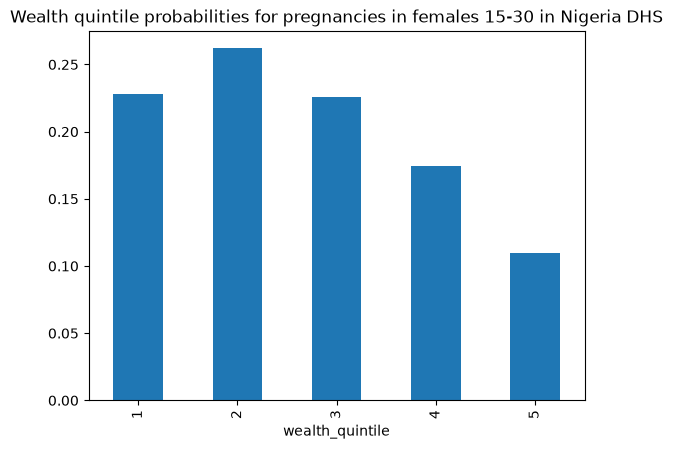

In [46]:
ax = wealth_quintile_probabilities.loc[("Female", 15.0, 30.0, "pregnant")].plot(
    kind="bar"
)
ax.set_title(
    f"Wealth quintile probabilities for pregnancies in females 15-30 in {location.title()} DHS"
)

In [47]:
wealth_quintile_probabilities.to_csv(
    f"{results_dir}/wealth_quintile_probabilities/{location}.csv",
)

## LBWSG

### Birth weight

In [48]:
birth_data["birth_weight_kilograms"] = birth_data.birth_weight_kilograms.replace(
    {"not weighed at birth": np.nan, "don't know": np.nan}
).astype(float)

In [49]:
weighted_avg_and_std(birth_data.birth_weight_kilograms, birth_data.weight)

mean                     3266.545675
sd                        680.943735
effective_sample_size    2910.969287
dtype: float64

In [50]:
birth_weight_disparities = birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.birth_weight_kilograms, df.weight)
)
birth_weight_disparities

,mean,sd,effective_sample_size
wealth_quintile,,,
1,3242.472648,561.923727,77.120654
2,3273.351609,690.807882,150.168661
3,3217.512638,683.610400,390.167286
4,3264.146651,661.856708,864.881390
5,3281.394096,695.836215,1431.384795


In [51]:
birth_weight_disparities = (
    birth_weight_disparities["mean"].rename("value").reset_index()
)
birth_weight_disparities

,wealth_quintile,value
0,1,3242.472648
1,2,3273.351609
2,3,3217.512638
3,4,3264.146651
4,5,3281.394096


In [52]:
birth_weight_disparities.to_csv(
    f"{results_dir}/birth_weight_disparities/{location}.csv", index=False
)

### Short gestation

All we have here is a self-reported duration of pregnancy.

In [53]:
# Basically no difference in mean
birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.duration_of_pregnancy, df.weight)
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,9.005899,0.153173,18253.651350
2,9.011374,0.199300,14313.370770
3,9.011841,0.221458,15065.481266
4,9.013253,0.242386,14773.325105
5,8.999714,0.233960,12562.313208


In [54]:
birth_data["short_gestation"] = np.where(
    birth_data.duration_of_pregnancy.isnull(),
    np.nan,
    birth_data.duration_of_pregnancy < 9.0,
)

In [55]:
weighted_avg_and_std(birth_data.short_gestation, birth_data.weight)

mean                         0.009410
sd                           0.096546
effective_sample_size    74306.928358
dtype: float64

In [56]:
birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.short_gestation, df.weight)
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.005051,0.070888,18253.651350
2,0.007922,0.088651,14313.370770
3,0.009923,0.099118,15065.481266
4,0.012339,0.110394,14773.325105
5,0.014137,0.118056,12562.313208


The trends in short gestation don't make intuitive sense (?), so we do not plan to use them in the sim.